# 02. Market VWAP 타겟 기준 EDA

`01_market_vwap_target.ipynb`에서 확정한 날짜별 전체 거래 VWAP 타겟을 기준으로, 모델링 전에 필요한 타겟 자체의 성질을 점검한다.

`market_vwap`, `target_logret_30d`, `target_logret_60d`가 시간축에서 어떻게 분포하는지, 품질 필터가 표본을 얼마나 바꾸는지, blended day와 긴 경과일이 타겟을 왜곡하는지 확인한다.

## 1. 분석 기준

| 항목 | 정의 |
|---|---|
| `market_vwap` | 같은 날짜에 실제 거래된 KAU vintage의 `acc_trdval` 합계를 `acc_trdvol` 합계로 나눈 날짜별 전체 거래 VWAP이다. |
| `target_logret_30d` | 기준일 이후 최소 30일이 지난 첫 거래일의 `market_vwap` 대비 로그수익률이다. |
| `target_logret_60d` | 기준일 이후 최소 60일이 지난 첫 거래일의 `market_vwap` 대비 로그수익률이다. |
| `actual_elapsed_days_*` | 기준일과 실제 매칭된 미래 거래일 사이의 달력일 수이다. |
| `is_blended` | 같은 날짜에 2개 이상의 KAU vintage 거래가 있어 전체 거래 VWAP가 합산 계산되었는지 표시한다. |

품질 기준은 `nominal_plus_15`로 둔다. 즉 30일 타겟은 실제 경과일 45일 이하, 60일 타겟은 실제 경과일 75일 이하를 기본 분석 표본으로 본다. 필터를 적용하지 않은 결과도 비교용으로 함께 확인한다.

In [1]:
# C01. 환경 설정 및 target parquet 로드
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'targets' / 'market_vwap_targets.parquet'
SCHEMA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'targets' / 'market_vwap_targets.schema.json'
OUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'target_eda'
OUT_FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'target_eda'
SAVE_OUTPUTS = True

if not TARGET_PATH.exists():
    raise FileNotFoundError(f'target parquet not found: {TARGET_PATH}')

if SAVE_OUTPUTS:
    OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
    OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

target = pd.read_parquet(TARGET_PATH).sort_values('trd_dd').reset_index(drop=True)
target['trd_dd'] = pd.to_datetime(target['trd_dd'])
target['year'] = target['trd_dd'].dt.year
target['month'] = target['trd_dd'].dt.to_period('M').astype(str)
target['log_market_vwap'] = np.log(target['market_vwap'])
target['daily_logret'] = target['log_market_vwap'].diff()
target['abs_daily_logret'] = target['daily_logret'].abs()

ELAPSED_CAPS = {'30d': 45, '60d': 75}
HORIZON_LABELS = {'30d': '30일', '60d': '60일'}
for horizon, cap in ELAPSED_CAPS.items():
    target[f'pass_{horizon}'] = (
        target[f'same_panel_{horizon}'].fillna(False)
        & target[f'target_logret_{horizon}'].notna()
        & target[f'actual_elapsed_days_{horizon}'].le(cap)
    )

target['pass_both_targets'] = target['pass_30d'] & target['pass_60d']

display_cols = [
    'trd_dd', 'market_vwap', 'total_trdvol', 'n_vintages', 'vintages', 'is_blended',
    'actual_elapsed_days_30d', 'target_logret_30d', 'pass_30d',
    'actual_elapsed_days_60d', 'target_logret_60d', 'pass_60d',
]

print(f'target_path: {TARGET_PATH}')
print(f'shape: {target.shape}')
print(f"date range: {target['trd_dd'].min().date()} ~ {target['trd_dd'].max().date()}")
print(f"schema_path exists: {SCHEMA_PATH.exists()}")
display(target[display_cols].head(5))
display(target[display_cols].tail(5))

target_path: /mnt/hgfs/Windows/Climate/data/processed/targets/market_vwap_targets.parquet
shape: (2132, 40)
date range: 2015-01-12 ~ 2026-04-23
schema_path exists: True


,trd_dd,market_vwap,total_trdvol,n_vintages,vintages,is_blended,actual_elapsed_days_30d,target_logret_30d,pass_30d,actual_elapsed_days_60d,target_logret_60d,pass_60d
0,2015-01-12,"8,185.210084",1190,1,KAU15,False,268.000000,0.322474,False,268.000000,0.322474,False
1,2015-01-13,"9,500.000000",50,1,KAU15,False,267.000000,0.173511,False,267.000000,0.173511,False
2,2015-01-14,"9,510.000000",100,1,KAU15,False,266.000000,0.172459,False,266.000000,0.172459,False
3,2015-01-16,"9,610.000000",40,1,KAU15,False,264.000000,0.161999,False,264.000000,0.161999,False
4,2015-10-07,"11,300.000000",12000,1,KAU15,False,63.000000,0.068403,False,63.000000,0.068403,True


,trd_dd,market_vwap,total_trdvol,n_vintages,vintages,is_blended,actual_elapsed_days_30d,target_logret_30d,pass_30d,actual_elapsed_days_60d,target_logret_60d,pass_60d
2127,2026-04-17,"16,948.051409",146978,1,KAU25,False,NaN,NaN,False,NaN,NaN,False
2128,2026-04-20,"16,584.285619",238654,1,KAU25,False,NaN,NaN,False,NaN,NaN,False
2129,2026-04-21,"16,494.158789",290599,1,KAU25,False,NaN,NaN,False,NaN,NaN,False
2130,2026-04-22,"16,375.206425",790239,1,KAU25,False,NaN,NaN,False,NaN,NaN,False
2131,2026-04-23,"16,528.322633",209179,1,KAU25,False,NaN,NaN,False,NaN,NaN,False


## 2. Target coverage

30일/60일 타겟이 어느 정도 생성되는지 확인한다. 전체 생성률만 보면 충분하지 않으므로, 연도별 생성률과 `nominal_plus_15` 적용 후 표본 수를 함께 본다.

,policy,target,elapsed_cap,sample_count,coverage_rate,date_start,date_end
0,no_elapsed_filter,target_logret_30d,NaN,2110,98.97%,2015-01-12,2026-03-24
1,no_elapsed_filter,target_logret_60d,NaN,2089,97.98%,2015-01-12,2026-02-20
2,nominal_plus_5,target_logret_30d,35.000000,2046,95.97%,2016-03-15,2026-03-24
3,nominal_plus_5,target_logret_60d,65.000000,2028,95.12%,2015-10-07,2026-02-20
4,nominal_plus_15,target_logret_30d,45.000000,2094,98.22%,2015-12-09,2026-03-24
5,nominal_plus_15,target_logret_60d,75.000000,2074,97.28%,2015-10-07,2026-02-20


,year,obs,raw_valid_30d,raw_rate_30d,pass_count_30d,pass_rate_30d,raw_valid_60d,raw_rate_60d,pass_count_60d,pass_rate_60d
0,2015,8,8,100.0%,2,25.0%,8,100.0%,4,50.0%
1,2016,58,58,100.0%,56,96.6%,58,100.0%,56,96.6%
2,2017,197,197,100.0%,197,100.0%,197,100.0%,197,100.0%
3,2018,146,146,100.0%,138,94.5%,146,100.0%,137,93.8%
4,2019,188,188,100.0%,188,100.0%,188,100.0%,188,100.0%
5,2020,235,235,100.0%,235,100.0%,235,100.0%,235,100.0%
6,2021,248,248,100.0%,248,100.0%,248,100.0%,248,100.0%
7,2022,245,245,100.0%,245,100.0%,245,100.0%,245,100.0%
8,2023,245,245,100.0%,245,100.0%,245,100.0%,245,100.0%
9,2024,244,244,100.0%,244,100.0%,244,100.0%,244,100.0%


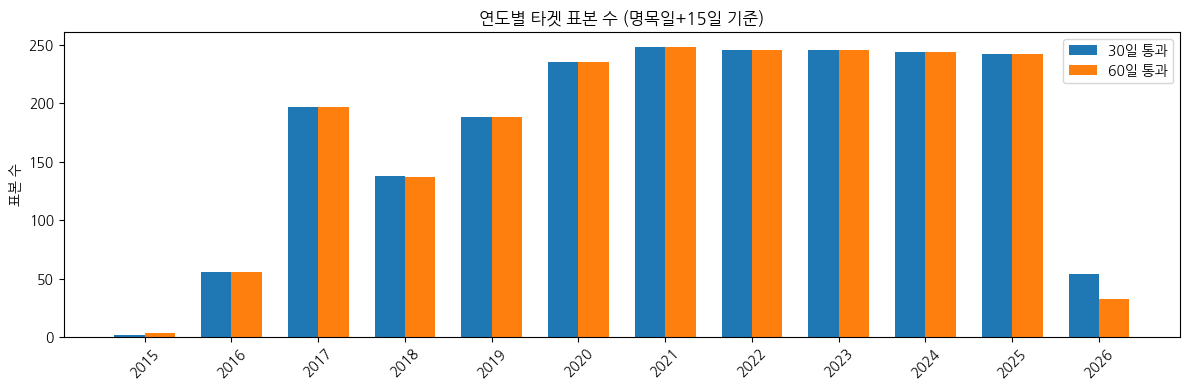

In [2]:
# C02. 전체 및 연도별 target coverage
policy_defs = {
    'no_elapsed_filter': {'30d': None, '60d': None},
    'nominal_plus_5': {'30d': 35, '60d': 65},
    'nominal_plus_15': {'30d': 45, '60d': 75},
}

coverage_rows = []
for policy, caps in policy_defs.items():
    for horizon, cap in caps.items():
        valid = target[f'target_logret_{horizon}'].notna() & target[f'same_panel_{horizon}'].fillna(False)
        if cap is not None:
            valid = valid & target[f'actual_elapsed_days_{horizon}'].le(cap)
        coverage_rows.append({
            'policy': policy,
            'target': f'target_logret_{horizon}',
            'elapsed_cap': cap,
            'sample_count': int(valid.sum()),
            'coverage_rate': valid.mean(),
            'date_start': target.loc[valid, 'trd_dd'].min(),
            'date_end': target.loc[valid, 'trd_dd'].max(),
        })
coverage = pd.DataFrame(coverage_rows)
coverage_display = coverage.copy()
coverage_display['coverage_rate'] = coverage_display['coverage_rate'].map(lambda x: f'{x:.2%}')
display(coverage_display)

if SAVE_OUTPUTS:
    coverage.to_csv(OUT_TABLE_DIR / 'coverage_by_policy.csv', index=False, encoding='utf-8-sig')

yearly_rows = []
for year, g in target.groupby('year'):
    row = {'year': year, 'obs': len(g)}
    for horizon in ['30d', '60d']:
        raw_valid = g[f'target_logret_{horizon}'].notna() & g[f'same_panel_{horizon}'].fillna(False)
        pass_valid = g[f'pass_{horizon}']
        row[f'raw_valid_{horizon}'] = int(raw_valid.sum())
        row[f'raw_rate_{horizon}'] = raw_valid.mean()
        row[f'pass_count_{horizon}'] = int(pass_valid.sum())
        row[f'pass_rate_{horizon}'] = pass_valid.mean()
    yearly_rows.append(row)

yearly_coverage = pd.DataFrame(yearly_rows)
yearly_coverage_display = yearly_coverage.copy()
for col in yearly_coverage_display.columns:
    if col.endswith('_rate_30d') or col.endswith('_rate_60d'):
        yearly_coverage_display[col] = yearly_coverage_display[col].map(lambda x: f'{x:.1%}')
display(yearly_coverage_display)

fig, ax = plt.subplots(figsize=(12, 4))
width = 0.35
x = np.arange(len(yearly_coverage))
ax.bar(x - width/2, yearly_coverage['pass_count_30d'], width=width, label='30일 통과')
ax.bar(x + width/2, yearly_coverage['pass_count_60d'], width=width, label='60일 통과')
ax.set_xticks(x)
ax.set_xticklabels(yearly_coverage['year'], rotation=45)
ax.set_title('연도별 타겟 표본 수 (명목일+15일 기준)')
ax.set_ylabel('표본 수')
ax.legend()
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'yearly_target_coverage.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. `market_vwap` 시계열 구조

가격 수준의 regime 변화, 거래량 급변, blended day가 어느 구간에 몰리는지 확인한다.

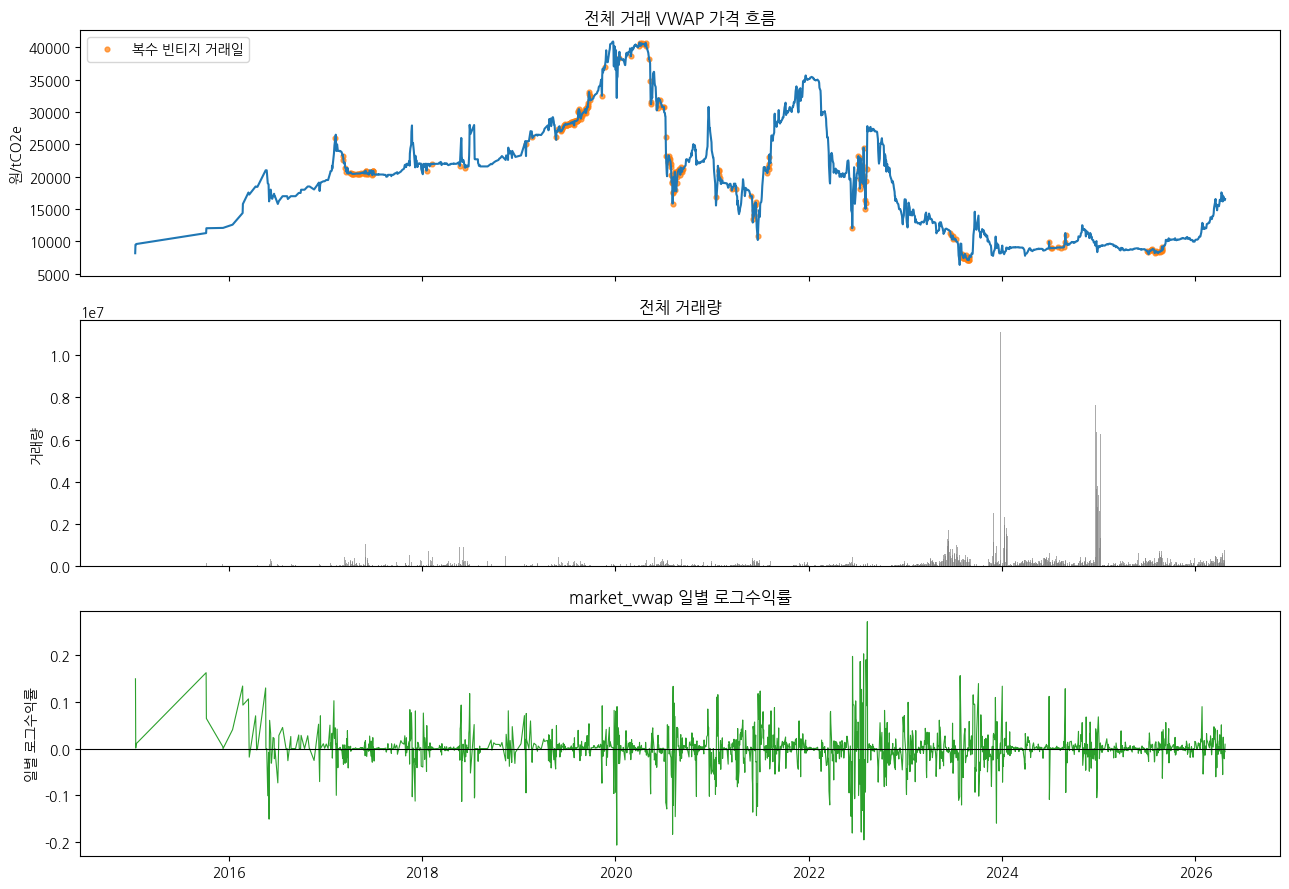

,year,obs,price_mean,price_median,price_min,price_max,volume_sum,blended_days,blended_rate,daily_volatility
0,2015,8,"10,544.401261","10,455.000000","8,185.210084","12,100.000000",321380,0,0.000000,0.071722
1,2016,58,"17,594.175741","17,416.667313","12,600.000000","21,000.000000",2562068,0,0.000000,0.046680
2,2017,197,"21,404.764243","20,604.081633","19,500.000000","27,930.000000",13707828,29,0.147208,0.022539
3,2018,146,"22,368.370804","22,000.000000","20,392.307692","28,024.149531",17530386,4,0.027397,0.027322
4,2019,188,"30,421.891635","28,758.654778","23,200.000000","40,900.000000",7828437,73,0.388298,0.021405
5,2020,235,"29,524.626289","29,388.678096","15,862.525279","40,736.842105",12562568,57,0.242553,0.037808
6,2021,248,"23,024.920395","20,562.863748","10,228.546953","35,651.098901",12742056,21,0.084677,0.036358
7,2022,245,"23,031.845485","21,267.572880","12,040.212515","35,435.714286",11508374,21,0.085714,0.054452
8,2023,245,"11,217.481917","11,615.012407","6,380.853458","16,473.239437",69314112,23,0.093878,0.042317
9,2024,244,"9,414.382102","9,065.540241","7,798.001706","12,513.219741",81427960,8,0.032787,0.025405


In [3]:
# C03. market_vwap 가격, 거래량, blended day 흐름
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(target['trd_dd'], target['market_vwap'], color='tab:blue', linewidth=1.5)
axes[0].scatter(
    target.loc[target['is_blended'], 'trd_dd'],
    target.loc[target['is_blended'], 'market_vwap'],
    s=12, color='tab:orange', alpha=0.7, label='복수 빈티지 거래일',
)
axes[0].set_title('전체 거래 VWAP 가격 흐름')
axes[0].set_ylabel('원/tCO2e')
axes[0].legend(loc='upper left')

axes[1].bar(target['trd_dd'], target['total_trdvol'], color='tab:gray', alpha=0.65, width=3)
axes[1].set_title('전체 거래량')
axes[1].set_ylabel('거래량')

axes[2].plot(target['trd_dd'], target['daily_logret'], color='tab:green', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('market_vwap 일별 로그수익률')
axes[2].set_ylabel('일별 로그수익률')

fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'market_vwap_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

monthly = (
    target.groupby('month')
    .agg(
        obs=('trd_dd', 'size'),
        month_start=('trd_dd', 'min'),
        month_end=('trd_dd', 'max'),
        market_vwap_mean=('market_vwap', 'mean'),
        market_vwap_last=('market_vwap', 'last'),
        total_trdvol_sum=('total_trdvol', 'sum'),
        blended_days=('is_blended', 'sum'),
        blended_rate=('is_blended', 'mean'),
        daily_volatility=('daily_logret', 'std'),
    )
    .reset_index()
)

yearly_market = (
    target.groupby('year')
    .agg(
        obs=('trd_dd', 'size'),
        price_mean=('market_vwap', 'mean'),
        price_median=('market_vwap', 'median'),
        price_min=('market_vwap', 'min'),
        price_max=('market_vwap', 'max'),
        volume_sum=('total_trdvol', 'sum'),
        blended_days=('is_blended', 'sum'),
        blended_rate=('is_blended', 'mean'),
        daily_volatility=('daily_logret', 'std'),
    )
    .reset_index()
)

display(yearly_market)

## 4. 30일/60일 target 분포

분석 표본은 `nominal_plus_15`를 통과한 행이다. 30일과 60일 타겟의 평균, 분산, 꼬리 두께, 방향 비율을 비교한다.

,policy,target,sample_count,mean,std,skew,kurtosis,min,p01,p05,p25,p50,p75,p95,p99,max,positive_rate,negative_rate,zero_rate
0,nominal_plus_15,target_logret_30d,2094,-0.003344,0.144583,0.309274,3.482795,-0.606963,-0.390453,-0.251766,-0.062288,0.004701,0.054618,0.219679,0.491025,0.720133,0.526266,0.460840,0.012894
1,no_elapsed_filter,target_logret_30d,2110,-0.002970,0.144673,0.306483,3.439883,-0.606963,-0.388117,-0.252166,-0.061929,0.004809,0.055464,0.220271,0.488707,0.720133,0.527014,0.460190,0.012796
2,nominal_plus_15,target_logret_60d,2074,-0.007296,0.203611,0.074035,1.653520,-0.645780,-0.505483,-0.389745,-0.101354,0.000361,0.090207,0.320094,0.554056,0.963707,0.502411,0.492285,0.005304
3,no_elapsed_filter,target_logret_60d,2089,-0.006521,0.203392,0.069943,1.651125,-0.645780,-0.504733,-0.389384,-0.100895,0.001317,0.090391,0.320454,0.552527,0.963707,0.504548,0.490187,0.005266


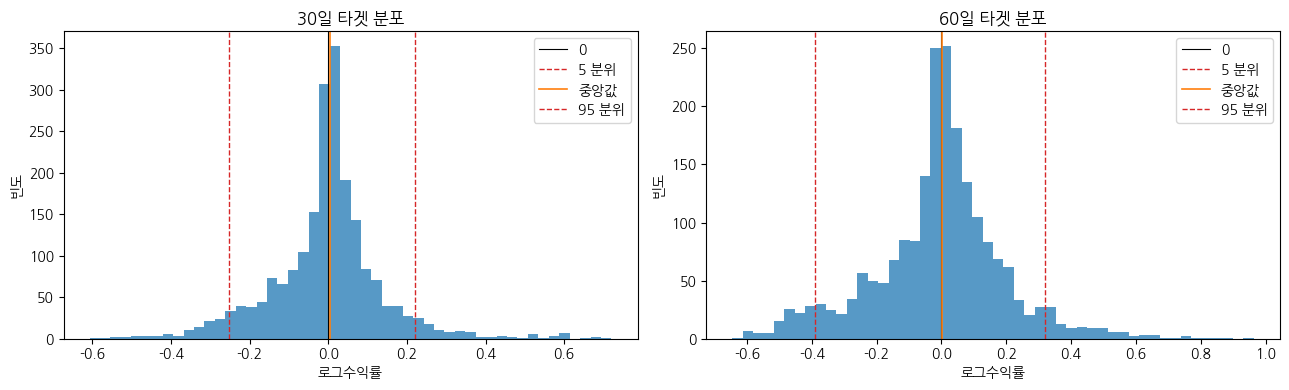

In [4]:
# C04. target 분포 요약과 histogram

def target_stats(df, horizon, mask):
    s = df.loc[mask, f'target_logret_{horizon}'].dropna()
    return {
        'target': f'target_logret_{horizon}',
        'sample_count': int(s.size),
        'mean': s.mean(),
        'std': s.std(),
        'skew': s.skew(),
        'kurtosis': s.kurt(),
        'min': s.min(),
        'p01': s.quantile(0.01),
        'p05': s.quantile(0.05),
        'p25': s.quantile(0.25),
        'p50': s.quantile(0.50),
        'p75': s.quantile(0.75),
        'p95': s.quantile(0.95),
        'p99': s.quantile(0.99),
        'max': s.max(),
        'positive_rate': s.gt(0).mean(),
        'negative_rate': s.lt(0).mean(),
        'zero_rate': s.eq(0).mean(),
    }

summary_rows = []
for horizon in ['30d', '60d']:
    summary_rows.append({'policy': 'nominal_plus_15', **target_stats(target, horizon, target[f'pass_{horizon}'])})
    raw_mask = target[f'target_logret_{horizon}'].notna() & target[f'same_panel_{horizon}'].fillna(False)
    summary_rows.append({'policy': 'no_elapsed_filter', **target_stats(target, horizon, raw_mask)})

target_distribution = pd.DataFrame(summary_rows)
display(target_distribution)
if SAVE_OUTPUTS:
    target_distribution.to_csv(OUT_TABLE_DIR / 'target_distribution_summary.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, horizon in zip(axes, ['30d', '60d']):
    s = target.loc[target[f'pass_{horizon}'], f'target_logret_{horizon}'].dropna()
    q05, q50, q95 = s.quantile([0.05, 0.50, 0.95])
    ax.hist(s, bins=50, color='tab:blue', alpha=0.75)
    ax.axvline(0, color='black', linewidth=0.8, label='0')
    ax.axvline(q05, color='tab:red', linestyle='--', linewidth=1.0, label='5 분위')
    ax.axvline(q50, color='tab:orange', linestyle='-', linewidth=1.2, label='중앙값')
    ax.axvline(q95, color='tab:red', linestyle='--', linewidth=1.0, label='95 분위')
    ax.set_title(f'{HORIZON_LABELS[horizon]} 타겟 분포')
    ax.set_xlabel('로그수익률')
    ax.set_ylabel('빈도')
    ax.legend(loc='upper right')

fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'target_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

,year,target,sample_count,mean,std,p05,p50,p95,positive_rate
0,2015,target_logret_30d,2,0.040491,0.000000,0.040491,0.040491,0.040491,1.000000
1,2015,target_logret_60d,4,0.105147,0.083746,0.013780,0.121213,0.174023,1.000000
2,2016,target_logret_30d,56,0.015520,0.083985,-0.185285,0.028988,0.129458,0.678571
3,2016,target_logret_60d,56,0.058926,0.124454,-0.135810,0.057970,0.278652,0.696429
4,2017,target_logret_30d,197,-0.010529,0.073567,-0.149151,-0.002460,0.130883,0.390863
5,2017,target_logret_60d,197,-0.017318,0.078790,-0.160071,-0.005021,0.088996,0.380711
6,2018,target_logret_30d,138,0.020231,0.074544,-0.049672,0.003498,0.215034,0.572464
7,2018,target_logret_60d,137,0.024473,0.087892,-0.084668,0.003164,0.235906,0.562044
8,2019,target_logret_30d,188,0.038223,0.056733,-0.068498,0.038792,0.126649,0.797872
9,2019,target_logret_60d,188,0.076165,0.071878,-0.037572,0.071423,0.212826,0.835106


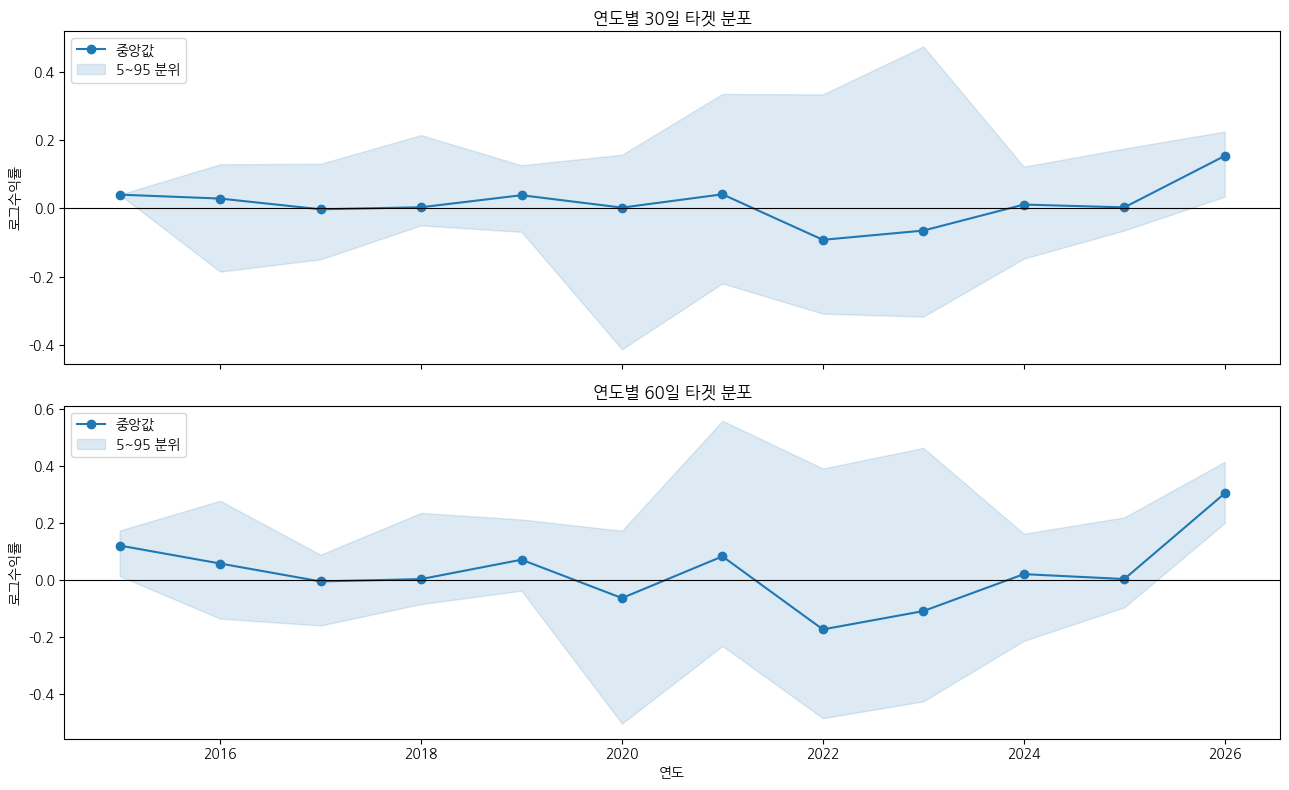

In [5]:
# C05. 연도별 target 분포
annual_target_rows = []
for year, g in target.groupby('year'):
    for horizon in ['30d', '60d']:
        s = g.loc[g[f'pass_{horizon}'], f'target_logret_{horizon}'].dropna()
        annual_target_rows.append({
            'year': year,
            'target': f'target_logret_{horizon}',
            'sample_count': int(s.size),
            'mean': s.mean(),
            'std': s.std(),
            'p05': s.quantile(0.05) if s.size else np.nan,
            'p50': s.quantile(0.50) if s.size else np.nan,
            'p95': s.quantile(0.95) if s.size else np.nan,
            'positive_rate': s.gt(0).mean() if s.size else np.nan,
        })
annual_target = pd.DataFrame(annual_target_rows)
display(annual_target)
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, horizon in zip(axes, ['30d', '60d']):
    p = annual_target[annual_target['target'].eq(f'target_logret_{horizon}')]
    ax.plot(p['year'], p['p50'], marker='o', label='중앙값', color='tab:blue')
    ax.fill_between(p['year'].to_numpy(), p['p05'].to_numpy(), p['p95'].to_numpy(), color='tab:blue', alpha=0.15, label='5~95 분위')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'연도별 {HORIZON_LABELS[horizon]} 타겟 분포')
    ax.set_ylabel('로그수익률')
    ax.legend(loc='upper left')
axes[-1].set_xlabel('연도')
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'annual_target_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. 30일 타겟과 60일 타겟의 관계

두 타겟의 상관, 방향 일치율, 극단값 동시 발생 여부를 확인한다.

,metric,value
0,sample_count,"2,064.000000"
1,pearson_corr,0.708809
2,spearman_corr,0.699118
3,sign_agreement,0.766957


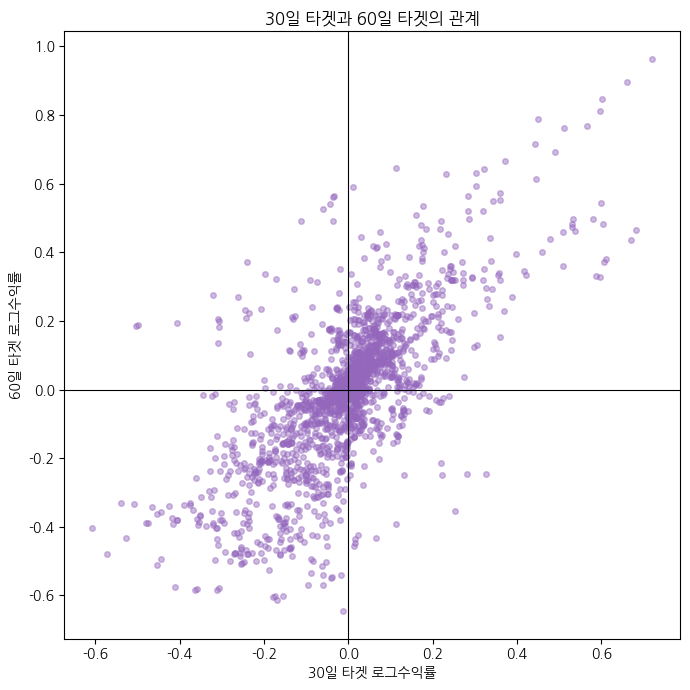

In [6]:
# C06. 30d/60d 관계
both = target.loc[target['pass_both_targets']].copy()
pearson_corr = both['target_logret_30d'].corr(both['target_logret_60d'], method='pearson')
spearman_corr = both['target_logret_30d'].corr(both['target_logret_60d'], method='spearman')
sign_agreement = (np.sign(both['target_logret_30d']) == np.sign(both['target_logret_60d'])).mean()

corr_summary = pd.DataFrame([
    {'metric': 'sample_count', 'value': len(both)},
    {'metric': 'pearson_corr', 'value': pearson_corr},
    {'metric': 'spearman_corr', 'value': spearman_corr},
    {'metric': 'sign_agreement', 'value': sign_agreement},
])
display(corr_summary)
if SAVE_OUTPUTS:
    corr_summary.to_csv(OUT_TABLE_DIR / 'target_horizon_relation.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(both['target_logret_30d'], both['target_logret_60d'], s=16, alpha=0.45, color='tab:purple')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('30일 타겟 로그수익률')
ax.set_ylabel('60일 타겟 로그수익률')
ax.set_title('30일 타겟과 60일 타겟의 관계')
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'target_30d_vs_60d.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Blended day 영향

`market_vwap`는 같은 날짜에 여러 vintage가 거래되면 전체 거래대금과 전체 거래량으로 합산 계산된다. \
따라서 blended day가 특정 연도에 몰리는지, blended day의 타겟 분포가 non-blended day와 다르게 움직이는지 확인한다.

,year,obs,blended_days,blended_rate,avg_n_vintages,max_n_vintages
0,2015,8,0,0.000000,1.000000,1
1,2016,58,0,0.000000,1.000000,1
2,2017,197,29,0.147208,1.147208,2
3,2018,146,4,0.027397,1.027397,2
4,2019,188,73,0.388298,1.393617,3
5,2020,235,57,0.242553,1.242553,2
6,2021,248,21,0.084677,1.084677,2
7,2022,245,21,0.085714,1.085714,2
8,2023,245,23,0.093878,1.093878,2
9,2024,244,8,0.032787,1.032787,2


,target,is_blended,sample_count,mean,std,p05,p50,p95,positive_rate,avg_total_trdvol,avg_vwap_range
0,target_logret_30d,False,1842,-0.013438,0.134972,-0.254487,0.000000,0.190919,0.499457,"134,376.118350",0.000000
1,target_logret_30d,True,252,0.070435,0.185691,-0.178386,0.043136,0.518796,0.722222,"136,458.321429","1,483.757937"
2,target_logret_60d,False,1823,-0.021981,0.197137,-0.390249,-0.004773,0.293343,0.469007,"132,510.442128",0.000000
3,target_logret_60d,True,251,0.099357,0.218037,-0.326438,0.107280,0.467460,0.745020,"136,069.920319","1,487.752988"


,target,n_vintages_group,sample_count,mean,std,p05,p50,p95
0,target_logret_30d,1,1842,-0.013438,0.134972,-0.254487,0.000000,0.190919
1,target_logret_30d,2,251,0.070693,0.186017,-0.178402,0.043720,0.519822
2,target_logret_30d,3+,1,0.005820,NaN,0.005820,0.005820,0.005820
3,target_logret_60d,1,1823,-0.021981,0.197137,-0.390249,-0.004773,0.293343
4,target_logret_60d,2,250,0.099171,0.218454,-0.330669,0.106563,0.467657
5,target_logret_60d,3+,1,0.145849,NaN,0.145849,0.145849,0.145849


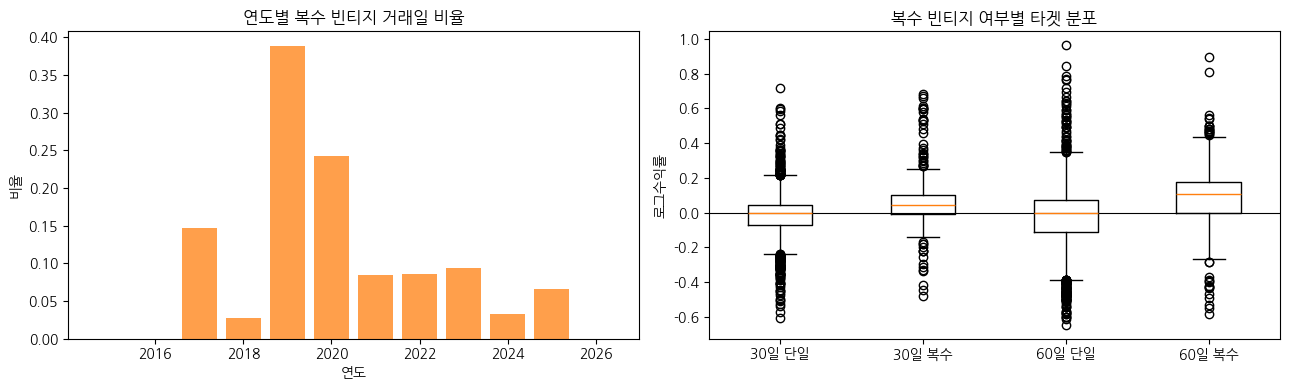

In [7]:
# C07. blended day 비율과 target 비교
blended_year = (
    target.groupby('year')
    .agg(
        obs=('trd_dd', 'size'),
        blended_days=('is_blended', 'sum'),
        blended_rate=('is_blended', 'mean'),
        avg_n_vintages=('n_vintages', 'mean'),
        max_n_vintages=('n_vintages', 'max'),
    )
    .reset_index()
)
display(blended_year)

blend_rows = []
for horizon in ['30d', '60d']:
    for is_blended, g in target.loc[target[f'pass_{horizon}']].groupby('is_blended'):
        s = g[f'target_logret_{horizon}'].dropna()
        blend_rows.append({
            'target': f'target_logret_{horizon}',
            'is_blended': bool(is_blended),
            'sample_count': int(s.size),
            'mean': s.mean(),
            'std': s.std(),
            'p05': s.quantile(0.05),
            'p50': s.quantile(0.50),
            'p95': s.quantile(0.95),
            'positive_rate': s.gt(0).mean(),
            'avg_total_trdvol': g['total_trdvol'].mean(),
            'avg_vwap_range': g['vwap_range'].mean(),
        })
blend_target_summary = pd.DataFrame(blend_rows)
display(blend_target_summary)

n_vintage_rows = []
target['n_vintages_group'] = np.where(target['n_vintages'].ge(3), '3+', target['n_vintages'].astype(str))
for horizon in ['30d', '60d']:
    for n_group, g in target.loc[target[f'pass_{horizon}']].groupby('n_vintages_group'):
        s = g[f'target_logret_{horizon}'].dropna()
        n_vintage_rows.append({
            'target': f'target_logret_{horizon}',
            'n_vintages_group': n_group,
            'sample_count': int(s.size),
            'mean': s.mean(),
            'std': s.std(),
            'p05': s.quantile(0.05),
            'p50': s.quantile(0.50),
            'p95': s.quantile(0.95),
        })
n_vintage_summary = pd.DataFrame(n_vintage_rows)
display(n_vintage_summary)

if SAVE_OUTPUTS:
    blend_target_summary.to_csv(OUT_TABLE_DIR / 'blended_target_summary.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(blended_year['year'], blended_year['blended_rate'], color='tab:orange', alpha=0.75)
axes[0].set_title('연도별 복수 빈티지 거래일 비율')
axes[0].set_ylabel('비율')
axes[0].set_xlabel('연도')

plot_data = [
    target.loc[target['pass_30d'] & ~target['is_blended'], 'target_logret_30d'].dropna(),
    target.loc[target['pass_30d'] & target['is_blended'], 'target_logret_30d'].dropna(),
    target.loc[target['pass_60d'] & ~target['is_blended'], 'target_logret_60d'].dropna(),
    target.loc[target['pass_60d'] & target['is_blended'], 'target_logret_60d'].dropna(),
]
axes[1].boxplot(plot_data, labels=['30일 단일', '30일 복수', '60일 단일', '60일 복수'], showfliers=True)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('복수 빈티지 여부별 타겟 분포')
axes[1].set_ylabel('로그수익률')
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'blended_day_effect.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. 실제 경과일 영향

거래가 드문 구간에서는 기준일 + 30일 또는 + 60일 이후 첫 관측일이 명목 horizon보다 훨씬 늦어질 수 있다. \
이 경우 target이 의도한 예측 기간과 달라질 수 있으므로, 실제 경과일 분포와 target 절댓값의 관계를 확인한다.

,target,sample_count,cap,min,p50,p90,p95,p99,max,over_cap_count,over_cap_rate,corr_abs_target_elapsed
0,target_logret_30d,2110,45,30.000000,30.000000,32.000000,34.000000,42.000000,268.000000,16,0.007583,0.032811
1,target_logret_60d,2089,75,60.000000,60.000000,62.000000,64.000000,72.120000,268.000000,15,0.007180,0.003900


,target,elapsed_bin,sample_count,mean_abs_target,mean_target,std_target,p50_target
0,target_logret_30d,<=35,2046,0.096730,-0.004600,0.144874,0.003838
1,target_logret_30d,36-45,48,0.074089,0.050204,0.121177,0.025154
2,target_logret_30d,46-65,12,0.094628,-0.007888,0.132760,-0.022765
3,target_logret_30d,66-75,0,NaN,NaN,NaN,NaN
4,target_logret_30d,76-120,0,NaN,NaN,NaN,NaN
5,target_logret_30d,>120,4,0.207611,0.207611,0.076752,0.172985
6,target_logret_60d,<=35,0,NaN,NaN,NaN,NaN
7,target_logret_60d,36-45,0,NaN,NaN,NaN,NaN
8,target_logret_60d,46-65,2028,0.144511,-0.008746,0.205051,0.000000
9,target_logret_60d,66-75,46,0.093079,0.056623,0.107772,0.055613


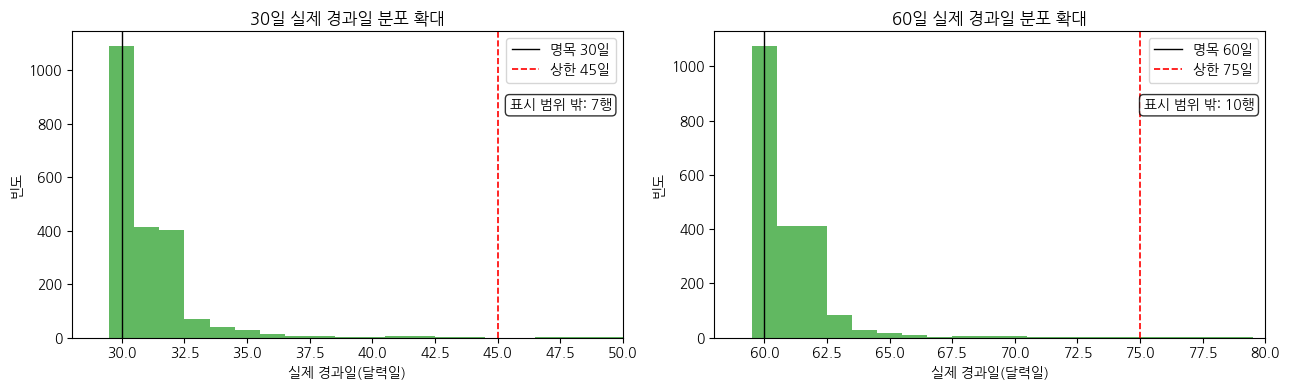

In [8]:
# C08. elapsed day 분포와 target 절댓값 관계
elapsed_rows = []
for horizon, cap in ELAPSED_CAPS.items():
    valid = target[f'target_logret_{horizon}'].notna() & target[f'same_panel_{horizon}'].fillna(False)
    e = target.loc[valid, f'actual_elapsed_days_{horizon}']
    y = target.loc[valid, f'target_logret_{horizon}']
    elapsed_rows.append({
        'target': f'target_logret_{horizon}',
        'sample_count': int(valid.sum()),
        'cap': cap,
        'min': e.min(),
        'p50': e.quantile(0.50),
        'p90': e.quantile(0.90),
        'p95': e.quantile(0.95),
        'p99': e.quantile(0.99),
        'max': e.max(),
        'over_cap_count': int(e.gt(cap).sum()),
        'over_cap_rate': e.gt(cap).mean(),
        'corr_abs_target_elapsed': y.abs().corr(e),
    })
elapsed_summary = pd.DataFrame(elapsed_rows)
display(elapsed_summary)

elapsed_bin_rows = []
for horizon in ['30d', '60d']:
    valid = target[f'target_logret_{horizon}'].notna() & target[f'same_panel_{horizon}'].fillna(False)
    tmp = target.loc[valid, ['trd_dd', f'actual_elapsed_days_{horizon}', f'target_logret_{horizon}']].copy()
    tmp['elapsed_bin'] = pd.cut(
        tmp[f'actual_elapsed_days_{horizon}'],
        bins=[0, 35, 45, 65, 75, 120, np.inf],
        labels=['<=35', '36-45', '46-65', '66-75', '76-120', '>120'],
    )
    for elapsed_bin, g in tmp.groupby('elapsed_bin', observed=False):
        s = g[f'target_logret_{horizon}'].dropna()
        elapsed_bin_rows.append({
            'target': f'target_logret_{horizon}',
            'elapsed_bin': str(elapsed_bin),
            'sample_count': int(s.size),
            'mean_abs_target': s.abs().mean(),
            'mean_target': s.mean(),
            'std_target': s.std(),
            'p50_target': s.quantile(0.50) if s.size else np.nan,
        })
elapsed_bin_summary = pd.DataFrame(elapsed_bin_rows)
display(elapsed_bin_summary)

if SAVE_OUTPUTS:
    elapsed_summary.to_csv(OUT_TABLE_DIR / 'elapsed_summary.csv', index=False, encoding='utf-8-sig')

elapsed_zoom_ranges = {'30d': (28, 50), '60d': (58, 80)}
nominal_days = {'30d': 30, '60d': 60}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, horizon in zip(axes, ['30d', '60d']):
    valid = target[f'target_logret_{horizon}'].notna() & target[f'same_panel_{horizon}'].fillna(False)
    e = target.loc[valid, f'actual_elapsed_days_{horizon}'].dropna()
    xmin, xmax = elapsed_zoom_ranges[horizon]
    zoom = e.between(xmin, xmax)
    outside_count = int((~zoom).sum())
    bins = np.arange(xmin - 0.5, xmax + 1.5, 1)

    ax.hist(e.loc[zoom], bins=bins, color='tab:green', alpha=0.75)
    ax.axvline(nominal_days[horizon], color='black', linewidth=1.0, label=f'명목 {nominal_days[horizon]}일')
    ax.axvline(ELAPSED_CAPS[horizon], color='red', linestyle='--', linewidth=1.2, label=f'상한 {ELAPSED_CAPS[horizon]}일')
    ax.set_xlim(xmin, xmax)
    ax.set_title(f'{HORIZON_LABELS[horizon]} 실제 경과일 분포 확대')
    ax.set_xlabel('실제 경과일(달력일)')
    ax.set_ylabel('빈도')
    ax.text(
        0.98, 0.78,
        f'표시 범위 밖: {outside_count:,}행',
        transform=ax.transAxes,
        ha='right', va='top', fontsize=10,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8},
    )
    ax.legend(loc='upper right')

fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUT_FIG_DIR / 'elapsed_day_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. 이상치 후보 점검

어느 날짜에서 발생했는지, 거래량이 낮은지, blended day인지, 가격 jump와 같이 움직였는지 확인한다. \
이후 모델링 단계에서는 제거보다 flag 또는 robustness check로 다루는 것을 기본으로 한다.

In [9]:
# C09. target 극단값, 가격 jump, 저유동성 후보
outlier_frames = []
for horizon in ['30d', '60d']:
    cols = [
        'trd_dd', 'market_vwap', 'total_trdvol', 'n_vintages', 'vintages', 'is_blended', 'vwap_range',
        f'future_date_{horizon}', f'future_vwap_{horizon}', f'actual_elapsed_days_{horizon}', f'target_logret_{horizon}',
    ]
    tmp = target.loc[target[f'pass_{horizon}'], cols].copy()
    tmp['target_horizon'] = horizon
    tmp['abs_target'] = tmp[f'target_logret_{horizon}'].abs()
    tmp = tmp.sort_values('abs_target', ascending=False).head(20)
    outlier_frames.append(tmp)

target_outliers = pd.concat(outlier_frames, ignore_index=True)
display(target_outliers)

jump_cols = ['trd_dd', 'market_vwap', 'daily_logret', 'abs_daily_logret', 'total_trdvol', 'n_vintages', 'vintages', 'is_blended', 'vwap_range']
price_jumps = target[jump_cols].dropna(subset=['daily_logret']).sort_values('abs_daily_logret', ascending=False).head(30)
display(price_jumps)

low_liquidity = target.sort_values('total_trdvol').head(30)[display_cols + ['daily_logret']]
display(low_liquidity)

,trd_dd,market_vwap,total_trdvol,n_vintages,vintages,is_blended,vwap_range,future_date_30d,future_vwap_30d,actual_elapsed_days_30d,target_logret_30d,target_horizon,abs_target,future_date_60d,future_vwap_60d,actual_elapsed_days_60d,target_logret_60d
0,2021-06-22,"10,228.546953",187709,1,KAU20,False,0,2021-07-22,"21,016.666667",30.000000,0.720133,30d,0.720133,NaT,NaN,NaN,NaN
1,2023-08-21,"7,386.681536",210501,2,"KAU22,KAU23",True,116,2023-09-20,"14,600.000000",30.000000,0.681343,30d,0.681343,NaT,NaN,NaN,NaN
2,2023-08-29,"7,164.221518",1018129,2,"KAU22,KAU23",True,86,2023-10-04,"14,000.000000",36.000000,0.669958,30d,0.669958,NaT,NaN,NaN,NaN
3,2021-06-21,"10,785.367223",225027,2,"KAU20,KAU21",True,2325,2021-07-21,"20,889.436620",30.000000,0.661053,30d,0.661053,NaT,NaN,NaN,NaN
4,2023-08-30,"7,592.035520",190934,2,"KAU22,KAU23",True,83,2023-10-04,"14,000.000000",35.000000,0.611958,30d,0.611958,NaT,NaN,NaN,NaN
5,2020-12-16,"28,554.176272",11278,1,KAU20,False,0,2021-01-15,"15,562.121212",30.000000,-0.606963,30d,0.606963,NaT,NaN,NaN,NaN
6,2023-08-31,"7,641.919390",40789,2,"KAU22,KAU23",True,118,2023-10-04,"14,000.000000",34.000000,0.605409,30d,0.605409,NaT,NaN,NaN,NaN
7,2023-08-22,"7,265.812359",616316,2,"KAU22,KAU23",True,452,2023-09-21,"13,299.738319",30.000000,0.604564,30d,0.604564,NaT,NaN,NaN,NaN
8,2021-06-23,"11,502.375683",103023,1,KAU20,False,0,2021-07-23,"21,002.777778",30.000000,0.602101,30d,0.602101,NaT,NaN,NaN,NaN
9,2022-08-03,"15,047.689821",100858,2,"KAU21,KAU22",True,14039,2022-09-02,"27,389.721654",30.000000,0.598943,30d,0.598943,NaT,NaN,NaN,NaN


,trd_dd,market_vwap,daily_logret,abs_daily_logret,total_trdvol,n_vintages,vintages,is_blended,vwap_range
1228,2022-08-10,"27,825.018745",0.270886,0.270886,4001,1,KAU22,False,0
599,2020-01-06,"32,181.818182",-0.206062,0.206062,5500,1,KAU19,False,0
1219,2022-07-27,"24,502.236864",0.202257,0.202257,127187,2,"KAU21,KAU22",True,7688
1189,2022-06-15,"14,658.928941",0.196798,0.196798,62863,1,KAU21,False,0
1220,2022-07-28,"20,161.335066",-0.194998,0.194998,42320,2,"KAU21,KAU22",True,9789
1226,2022-08-05,"19,365.504825",0.189749,0.189749,13886,2,"KAU21,KAU22",True,11014
1210,2022-07-14,"21,877.060749",0.185874,0.185874,53779,2,"KAU21,KAU22",True,7498
732,2020-08-04,"15,862.525279",-0.182995,0.182995,61811,2,"KAU19,KAU20",True,5042
1188,2022-06-14,"12,040.212515",-0.180347,0.180347,447827,2,"KAU21,KAU22",True,10
1212,2022-07-18,"19,144.260274",-0.178270,0.178270,7300,1,KAU21,False,0


,trd_dd,market_vwap,total_trdvol,n_vintages,vintages,is_blended,actual_elapsed_days_30d,target_logret_30d,pass_30d,actual_elapsed_days_60d,target_logret_60d,pass_60d,daily_logret
370,2018-07-02,"26,600.000000",2,1,KAU17,False,30.000000,-0.189869,True,65.000000,-0.208218,True,-0.052155
3,2015-01-16,"9,610.000000",40,1,KAU15,False,264.000000,0.161999,False,264.000000,0.161999,False,0.010460
406,2018-12-07,"24,000.000000",43,1,KAU18,False,33.000000,-0.029600,True,63.000000,0.060625,True,0.046893
1,2015-01-13,"9,500.000000",50,1,KAU15,False,267.000000,0.173511,False,267.000000,0.173511,False,0.148963
96,2017-03-07,"23,400.000000",70,1,KAU17,False,30.000000,-0.127984,True,62.000000,-0.132535,True,0.008134
2,2015-01-14,"9,510.000000",100,1,KAU15,False,266.000000,0.172459,False,266.000000,0.172459,False,0.001052
8,2016-01-15,"12,600.000000",100,1,KAU15,False,38.000000,0.133531,True,60.000000,0.332374,True,0.040491
244,2017-11-29,"24,500.000000",178,1,KAU17,False,35.000000,-0.183515,True,61.000000,-0.125980,True,-0.029490
144,2017-05-23,"20,650.000000",243,1,KAU16,False,30.000000,0.016807,True,62.000000,-0.014634,True,0.000000
1510,2023-10-04,"14,000.000000",319,1,KAU23,False,30.000000,-0.268195,True,61.000000,-0.475774,True,0.138816


## 9. 모델링 split 후보

타겟 EDA 이후 feature를 붙일 때는 시간 순서를 보존해야 한다. 여기서는 split과 walk-forward 후보를 표본 수 기준으로 먼저 점검한다.

In [10]:
# C10. 고정 split 및 walk-forward 후보 표본 수
split_defs = [
    {'split': 'train', 'start': '2015-01-01', 'end': '2021-12-31'},
    {'split': 'valid', 'start': '2022-01-01', 'end': '2023-12-31'},
    {'split': 'test', 'start': '2024-01-01', 'end': '2026-12-31'},
]

split_rows = []
for spec in split_defs:
    mask = target['trd_dd'].between(pd.Timestamp(spec['start']), pd.Timestamp(spec['end']))
    g = target.loc[mask]
    split_rows.append({
        'split': spec['split'],
        'date_start': spec['start'],
        'date_end': spec['end'],
        'raw_obs': len(g),
        'pass_30d': int(g['pass_30d'].sum()),
        'pass_60d': int(g['pass_60d'].sum()),
        'pass_both_targets': int(g['pass_both_targets'].sum()),
        'blended_rate': g['is_blended'].mean(),
    })
split_summary = pd.DataFrame(split_rows)
display(split_summary)

fold_rows = []
for test_year in range(2021, int(target['year'].max()) + 1):
    train_mask = target['year'].lt(test_year)
    test_mask = target['year'].eq(test_year)
    fold_rows.append({
        'fold': f'test_{test_year}',
        'train_start': target.loc[train_mask, 'trd_dd'].min(),
        'train_end': target.loc[train_mask, 'trd_dd'].max(),
        'test_start': target.loc[test_mask, 'trd_dd'].min(),
        'test_end': target.loc[test_mask, 'trd_dd'].max(),
        'train_pass_30d': int(target.loc[train_mask, 'pass_30d'].sum()),
        'train_pass_60d': int(target.loc[train_mask, 'pass_60d'].sum()),
        'test_pass_30d': int(target.loc[test_mask, 'pass_30d'].sum()),
        'test_pass_60d': int(target.loc[test_mask, 'pass_60d'].sum()),
    })
walk_forward_summary = pd.DataFrame(fold_rows)
display(walk_forward_summary)

if SAVE_OUTPUTS:
    split_summary.to_csv(OUT_TABLE_DIR / 'fixed_split_sample_counts.csv', index=False, encoding='utf-8-sig')

,split,date_start,date_end,raw_obs,pass_30d,pass_60d,pass_both_targets,blended_rate
0,train,2015-01-01,2021-12-31,1080,1064,1065,1055,0.170370
1,valid,2022-01-01,2023-12-31,490,490,490,490,0.089796
2,test,2024-01-01,2026-12-31,562,540,519,519,0.042705


,fold,train_start,train_end,test_start,test_end,train_pass_30d,train_pass_60d,test_pass_30d,test_pass_60d
0,test_2021,2015-01-12,2020-12-30,2021-01-04,2021-12-30,816,817,248,248
1,test_2022,2015-01-12,2021-12-30,2022-01-03,2022-12-29,1064,1065,245,245
2,test_2023,2015-01-12,2022-12-29,2023-01-02,2023-12-28,1309,1310,245,245
3,test_2024,2015-01-12,2023-12-28,2024-01-02,2024-12-30,1554,1555,244,244
4,test_2025,2015-01-12,2024-12-30,2025-01-02,2025-12-30,1798,1799,242,242
5,test_2026,2015-01-12,2025-12-30,2026-01-02,2026-04-23,2040,2041,54,33


## 10. 산출물 저장 확인

Target EDA 요약 JSON과 핵심 산출물 경로를 확인한다.

In [11]:
# C11. 산출물 저장 확인
summary = {
    'n_rows': len(target),
    'date_start': target['trd_dd'].min().date().isoformat(),
    'date_end': target['trd_dd'].max().date().isoformat(),
    'pass_30d': int(target['pass_30d'].sum()),
    'pass_60d': int(target['pass_60d'].sum()),
    'pass_both_targets': int(target['pass_both_targets'].sum()),
    'blended_days': int(target['is_blended'].sum()),
    'blended_rate': float(target['is_blended'].mean()),
    'max_elapsed_30d': float(target.loc[target['target_logret_30d'].notna(), 'actual_elapsed_days_30d'].max()),
    'max_elapsed_60d': float(target.loc[target['target_logret_60d'].notna(), 'actual_elapsed_days_60d'].max()),
    'corr_30d_60d': float(pearson_corr),
    'sign_agreement_30d_60d': float(sign_agreement),
}

if SAVE_OUTPUTS:
    summary_path = OUT_TABLE_DIR / 'target_eda_summary.json'
    summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
    artifact_summary = pd.DataFrame([
        {'artifact': 'coverage', 'path': str((OUT_TABLE_DIR / 'coverage_by_policy.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'target distribution', 'path': str((OUT_TABLE_DIR / 'target_distribution_summary.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'horizon relation', 'path': str((OUT_TABLE_DIR / 'target_horizon_relation.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'blended summary', 'path': str((OUT_TABLE_DIR / 'blended_target_summary.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'elapsed summary', 'path': str((OUT_TABLE_DIR / 'elapsed_summary.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'fixed split', 'path': str((OUT_TABLE_DIR / 'fixed_split_sample_counts.csv').relative_to(PROJECT_ROOT))},
        {'artifact': 'summary json', 'path': str(summary_path.relative_to(PROJECT_ROOT))},
    ])
    display(artifact_summary)
else:
    display(pd.DataFrame([summary]))

,artifact,path
0,coverage,outputs/tables/target_eda/coverage_by_policy.csv
1,target distribution,outputs/tables/target_eda/target_distribution_...
2,horizon relation,outputs/tables/target_eda/target_horizon_relat...
3,blended summary,outputs/tables/target_eda/blended_target_summa...
4,elapsed summary,outputs/tables/target_eda/elapsed_summary.csv
5,fixed split,outputs/tables/target_eda/fixed_split_sample_c...
6,summary json,outputs/tables/target_eda/target_eda_summary.json
